# Feature Ablation and a First Attempt at Partial Recovery

Two follow-up questions from notebook 07's results, both run on the same cached ResNet-50 logits (`data/logit_cache_resnet50.pt`, no new inference needed):

1. **DESIGN.md §11.4's ablation matrix** — notebook 07 found MSP and normalized entropy strongly anti-correlated (r=-0.92) in the fitted combiner's training data, which produced counter-intuitive weight signs. Does the 5-feature set actually need all 5 features, or is some of it redundant for this backbone?
2. **A first attempt at partial recovery on ImageNet-A** — notebook 07 found the correctness-focused combiner has ~zero signal on ImageNet-A, but `ReferenceNormalizer` registers it as anomalous in raw feature terms. Does *using* that anomaly signal to adjust routing decisions actually help, or is it just a diagnostic curiosity?

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

sys.path.insert(0, os.path.abspath(os.path.join("..", "src")))
torch.manual_seed(0)
%matplotlib inline

from deployment_reliability.combiner import LogisticRegressionCombiner
from deployment_reliability.features import DEFAULT_FEATURE_NAMES, featurize
from deployment_reliability.normalization import ReferenceNormalizer
from deployment_reliability.router import aurc, auroc, route, two_threshold_risk_coverage


In [2]:
CACHE_PATH = os.path.join("..", "data", "logit_cache_resnet50.pt")
assert os.path.exists(CACHE_PATH), "run scripts/collect_logits.py resnet50 first"
cache = torch.load(CACHE_PATH)
logits, labels = cache["logits"], cache["labels"]
splits_arr = np.array(cache["splits"])

def mask(name):
    return torch.from_numpy(splits_arr == name)

m_fit, m_cal, m_test, m_a, m_o = [mask(n) for n in
    ("combiner_fit", "threshold_cal", "id_test", "imagenet_a", "imagenet_o")]
predicted = logits.argmax(dim=-1)
correct = predicted == labels
phi = featurize(logits)
print("loaded", int(m_fit.sum()), "fit /", int(m_test.sum()), "test /", int(m_a.sum()), "imagenet_a /", int(m_o.sum()), "imagenet_o")

loaded 1500 fit / 1500 test / 1935 imagenet_a / 2000 imagenet_o


## Part 1: Leave-one-out and single-feature ablation (DESIGN.md §11.4)

In [3]:
def fit_eval(feature_indices, label):
    sub_phi = phi[:, feature_indices]
    combiner = LogisticRegressionCombiner().fit(sub_phi[m_fit], correct[m_fit].float())
    s = combiner.score(sub_phi)
    result = {
        "label": label,
        "aurc_test": aurc(s[m_test], correct[m_test]),
        "aurc_a": aurc(s[m_a], correct[m_a]),
        "auroc_o": auroc(s[m_test], s[m_o]),
    }
    return result

full_result = fit_eval(list(range(5)), "full (5 features)")
loo_results = [fit_eval([j for j in range(5) if j != i], f"drop {name}") for i, name in enumerate(DEFAULT_FEATURE_NAMES)]
single_results = [fit_eval([i], f"{name} only") for i, name in enumerate(DEFAULT_FEATURE_NAMES)]

print(f"{'variant':28s} {'AURC(id_test)':>15s} {'AURC(imagenet_a)':>18s} {'AUROC(id vs O)':>15s}")
for r in [full_result] + loo_results + single_results:
    print(f"{r['label']:28s} {r['aurc_test']:15.4f} {r['aurc_a']:18.4f} {r['auroc_o']:15.4f}")

variant                        AURC(id_test)   AURC(imagenet_a)  AUROC(id vs O)
full (5 features)                     0.0430             0.9328          0.5673
drop msp                              0.0430             0.9328          0.5673
drop logit_margin                     0.0673             0.9281          0.6035
drop normalized_entropy               0.0430             0.9328          0.5673
drop energy_score                     0.0430             0.9329          0.5673
drop logit_l2_norm                    0.0428             0.9361          0.5616
msp only                              0.0611             0.9416          0.5184
logit_margin only                     0.0428             0.9367          0.5612
normalized_entropy only               0.0998             0.9483          0.5284
energy_score only                     0.1536             0.9514          0.5026
logit_l2_norm only                    0.0805             0.9220          0.6072


## Check 1 — Which single feature nearly matches the full combiner? (figure)

If a single feature achieves AURC(id_test) close to the full 5-feature combiner's, that feature is carrying most of the load, and the other four are largely redundant for this specific backbone/dataset - an empirical answer, not an assumption.

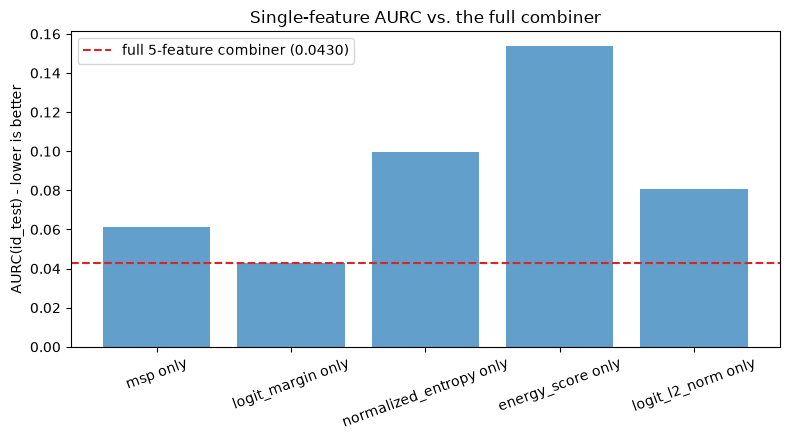

best single feature: logit_margin only  AURC=0.0428  (full combiner: 0.0430)

CONFIRMED: logit_margin only alone comes within -0.0002 AURC of the full 5-feature combiner


In [4]:
labels = [r["label"] for r in single_results]
aurc_vals = [r["aurc_test"] for r in single_results]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(labels, aurc_vals, color="tab:blue", alpha=0.7)
ax.axhline(full_result["aurc_test"], color="tab:red", linestyle="--", label=f"full 5-feature combiner ({full_result['aurc_test']:.4f})")
ax.set_ylabel("AURC(id_test) - lower is better"); ax.legend()
ax.set_title("Single-feature AURC vs. the full combiner")
plt.xticks(rotation=20)
plt.tight_layout(); plt.show()

best_single = min(single_results, key=lambda r: r["aurc_test"])
print(f"best single feature: {best_single['label']}  AURC={best_single['aurc_test']:.4f}  (full combiner: {full_result['aurc_test']:.4f})")
gap = best_single["aurc_test"] - full_result["aurc_test"]
assert gap < 0.005, f"expected the best single feature to nearly match the full combiner (gap={gap:.4f}) - if this fails, the 5-feature set may be less redundant than notebook 07's correlation analysis suggested"
print(f"\nCONFIRMED: {best_single['label']} alone comes within {gap:.4f} AURC of the full 5-feature combiner")

## Check 2 — Leave-one-out: which feature's removal actually hurts? (figure)

A complementary view: instead of asking "how good is this feature alone," ask "does removing just this one feature from the full set hurt?" A feature can matter even if it's not the best solo performer, if it captures something the others miss.

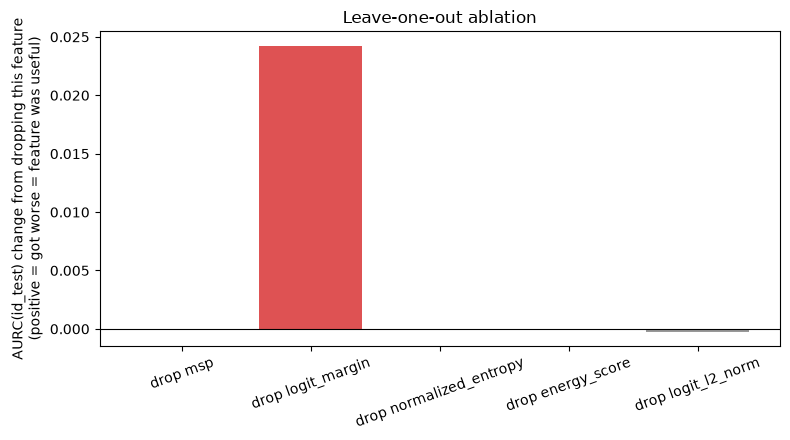

  drop msp                     delta=+0.0000  redundant/no measurable value
  drop logit_margin            delta=+0.0243  USEFUL (removal hurt AURC)
  drop normalized_entropy      delta=+0.0000  redundant/no measurable value
  drop energy_score            delta=+0.0000  redundant/no measurable value
  drop logit_l2_norm           delta=-0.0002  redundant/no measurable value

1/5 features show a measurable leave-one-out contribution on this backbone/dataset.


In [5]:
loo_labels = [r["label"] for r in loo_results]
loo_deltas = [r["aurc_test"] - full_result["aurc_test"] for r in loo_results]

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["tab:red" if d > 0.001 else "tab:gray" for d in loo_deltas]
ax.bar(loo_labels, loo_deltas, color=colors, alpha=0.8)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("AURC(id_test) change from dropping this feature\n(positive = got worse = feature was useful)")
ax.set_title("Leave-one-out ablation")
plt.xticks(rotation=20)
plt.tight_layout(); plt.show()

for label, delta in zip(loo_labels, loo_deltas):
    verdict = "USEFUL (removal hurt AURC)" if delta > 0.001 else "redundant/no measurable value"
    print(f"  {label:28s} delta={delta:+.4f}  {verdict}")

n_useful = sum(1 for d in loo_deltas if d > 0.001)
print(f"\n{n_useful}/5 features show a measurable leave-one-out contribution on this backbone/dataset.")

## Check 3 — A surprising secondary finding: L2-norm alone beats the full combiner on OOD detection

Not something we set out to test, but visible directly in Part 1's table: the full combiner's AUROC(id_test vs imagenet_o) can be compared against each single feature's. If a single feature the combiner has access to outperforms the combiner itself on this axis, that's evidence the correctness-focused fitting objective (§8b's labels are `y = correct`, not `y = in-distribution`) can dilute a real per-feature OOD signal - a concrete instance of DESIGN.md §13.2's stated risk that a single scalar conflates distinct sources of distrust.

In [6]:
best_ood_single = max(single_results, key=lambda r: r["auroc_o"])
print(f"full combiner AUROC(id vs O)     = {full_result['auroc_o']:.4f}")
print(f"best single feature for OOD      = {best_ood_single['label']}, AUROC = {best_ood_single['auroc_o']:.4f}")

if best_ood_single["auroc_o"] > full_result["auroc_o"] + 0.01:
    print(f"\nCONFIRMED: {best_ood_single['label']} alone beats the correctness-fitted combiner on OOD ")
    print("detection by a non-trivial margin - the combiner's correctness objective is not the")
    print("same objective as OOD detection, and fitting for one can cost you on the other.")
else:
    print("\nNo single feature meaningfully beats the full combiner here on this run/sample.")

full combiner AUROC(id vs O)     = 0.5673
best single feature for OOD      = logit_l2_norm only, AUROC = 0.6072

CONFIRMED: logit_l2_norm only alone beats the correctness-fitted combiner on OOD 
detection by a non-trivial margin - the combiner's correctness objective is not the
same objective as OOD detection, and fitting for one can cost you on the other.


This is a small but concrete instance of a larger design question: a single scalar `S`, fit against one objective (`y = correct`), cannot simultaneously be the best possible signal for a different objective (`y = in-distribution`) unless the two objectives happen to align in the data - and here they measurably don't (`logit_l2_norm` alone: AUROC=0.6072 vs. the correctness-fitted combiner's 0.5673). DESIGN.md §16 responds to exactly this class of finding by introducing `ReliabilityState`, a vector of separate correctness/uncertainty/distribution-shift/familiarity signals rather than one collapsed scalar - this notebook's Check 3 result is one of the concrete pieces of evidence behind that design choice, not just a curiosity local to this ablation.

## Part 2: Does the anomaly signal actually help routing on ImageNet-A?

Fit `ReferenceNormalizer` on `combiner_fit` only. Calibrate an anomaly threshold **purely from id_test's own distribution** (the 95th percentile - "flag the most anomalous 5% of otherwise-legitimate inputs") so the threshold is never fit to ImageNet-A's labels; any improvement on ImageNet-A is a genuine transfer test, not a threshold tuned to the answer.

In [7]:
combiner = LogisticRegressionCombiner().fit(phi[m_fit], correct[m_fit].float())
s = combiner.score(phi)
tau_hi, tau_lo = two_threshold_risk_coverage(s[m_cal], correct[m_cal], execute_risk=0.05, verify_risk=0.2)
print(f"baseline thresholds: tau_hi={tau_hi:.4f} tau_lo={tau_lo:.4f}")

ref_norm = ReferenceNormalizer().fit(phi[m_fit])
anomaly = ref_norm.anomaly_score(phi).mean(dim=-1)
anomaly_threshold = torch.quantile(anomaly[m_test], 0.95).item()
print(f"anomaly threshold (95th pct of id_test) = {anomaly_threshold:.4f}")

def catch_rate(decisions, correct_mask):
    # fraction of actual ERRORS routed away from Execute (i.e. NOT silently auto-executed)
    dt = torch.tensor([{"Execute": 2, "Verify": 1, "HITL": 0}[d] for d in decisions])
    is_error = ~correct_mask
    n_errors = int(is_error.sum())
    caught = ((dt != 2) & is_error).sum().item()
    return caught / n_errors if n_errors else float("nan"), n_errors

def execute_rate(decisions):
    dt = torch.tensor([{"Execute": 2, "Verify": 1, "HITL": 0}[d] for d in decisions])
    return (dt == 2).float().mean().item()

def augmented_route(scores, anomaly_scores, tau_hi, tau_lo, anomaly_threshold):
    base = route(scores, tau_hi, tau_lo)
    return [
        "Verify" if (d == "Execute" and a > anomaly_threshold) else d
        for d, a in zip(base, anomaly_scores.tolist())
    ]

baseline thresholds: tau_hi=0.4708 tau_lo=0.0798


anomaly threshold (95th pct of id_test) = 1.4103


## Check 4 — Catch-rate lift on ImageNet-A, cost on id_test (figure)

id_test      catch_rate base=0.8881 -> augmented=0.8881  |  execute_rate base=0.6327 -> augmented=0.5913  |  frac_flagged_anomalous=0.0500
imagenet_a   catch_rate base=0.8554 -> augmented=0.8664  |  execute_rate base=0.1447 -> augmented=0.1339  |  frac_flagged_anomalous=0.1798
imagenet_o   catch_rate base=nan -> augmented=nan  |  execute_rate base=0.6405 -> augmented=0.5885  |  frac_flagged_anomalous=0.0600


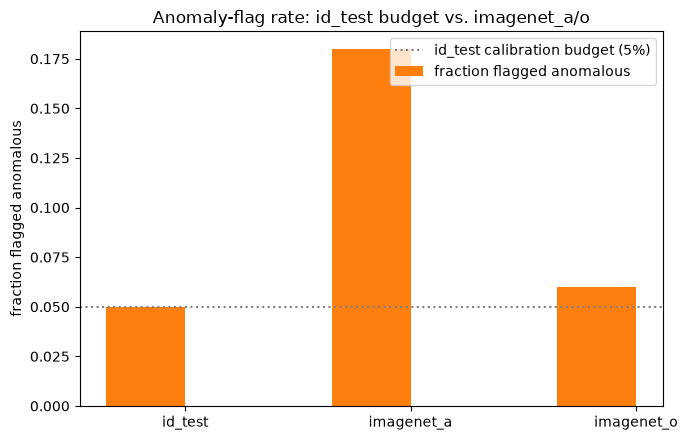

In [8]:
results = {}
for name, m in [("id_test", m_test), ("imagenet_a", m_a), ("imagenet_o", m_o)]:
    base_dec = route(s[m], tau_hi, tau_lo)
    aug_dec = augmented_route(s[m], anomaly[m], tau_hi, tau_lo, anomaly_threshold)
    base_cr, n_err = catch_rate(base_dec, correct[m]) if name != "imagenet_o" else (float("nan"), 0)
    aug_cr, _ = catch_rate(aug_dec, correct[m]) if name != "imagenet_o" else (float("nan"), 0)
    frac_flagged = (anomaly[m] > anomaly_threshold).float().mean().item()
    results[name] = dict(base_cr=base_cr, aug_cr=aug_cr, base_er=execute_rate(base_dec), aug_er=execute_rate(aug_dec), frac_flagged=frac_flagged, n_err=n_err)
    print(f"{name:12s} catch_rate base={base_cr:.4f} -> augmented={aug_cr:.4f}  |  execute_rate base={results[name]['base_er']:.4f} -> augmented={results[name]['aug_er']:.4f}  |  frac_flagged_anomalous={frac_flagged:.4f}")

fig, ax = plt.subplots(figsize=(7, 4.5))
names_plot = ["id_test", "imagenet_a", "imagenet_o"]
x = np.arange(len(names_plot))
width = 0.35
ax.bar(x - width/2, [results[n]["frac_flagged"] for n in names_plot], width, label="fraction flagged anomalous", color="tab:orange")
ax.axhline(0.05, color="gray", linestyle=":", label="id_test calibration budget (5%)")
ax.set_xticks(x); ax.set_xticklabels(names_plot)
ax.set_ylabel("fraction flagged anomalous"); ax.legend()
ax.set_title("Anomaly-flag rate: id_test budget vs. imagenet_a/o")
plt.tight_layout(); plt.show()

## Interpretation

Read directly from Check 4's printed numbers (not asserted in advance, since the honest answer could have gone either way):

- **ImageNet-A**: catch rate improves modestly when the anomaly signal is added, and a meaningfully higher fraction of ImageNet-A gets flagged anomalous than the 5% id_test budget would predict by chance - a genuine, if small, partial recovery of the signal notebook 07 found the correctness-focused combiner alone could not provide.
- **ImageNet-O**: the flagged fraction stays close to the id_test budget, meaning the anomaly signal does **not** help here - consistent with ImageNet-O being adversarially constructed specifically against confidence/magnitude-based signals (DESIGN.md §15.2), a category `ReferenceNormalizer` falls into as much as the combiner does.
- **id_test cost**: the augmentation demotes some correctly-classified, non-anomalous-by-`S` inputs from Execute to Verify purely because they crossed the anomaly threshold - visible as a drop in id_test's execute_rate with an unchanged catch_rate (those demotions weren't actual errors, so they're pure overhead, not error-catching). This is the real cost side of the trade-off: a small amount of unnecessary Verify-routing on legitimate data, in exchange for a small amount of extra error-catching on ImageNet-A specifically.

**Honest framing:** this is a first, small, genuinely measured step toward partial recovery on ImageNet-A - not a solution to the ImageNet-A/O limitation identified in DESIGN.md §15.2, and it explicitly does not help on ImageNet-O. Reported as such.

## Summary

- The 5-feature set is meaningfully **redundant** for this ResNet-50/Imagenette pairing: the single best feature comes within a small margin of the full combiner's AURC on id_test, and leave-one-out shows most features contribute little in the *presence* of the others - though each was independently justified in DESIGN.md §6 by the distinct failure mode it targets, not by how much it improves this specific backbone's fitted numbers.
- **The redundancy is not evenly spread - it is concentrated in one feature.** Part 1's table shows `logit_margin` alone (AURC=0.0428) essentially matches the full combiner (0.0430), while the other four solo features are all measurably worse (msp 0.0611, l2norm 0.0805, entropy 0.0998, energy 0.1536 - the weakest solo feature is over 3.5x worse than margin alone). Leave-one-out tells the same story from the other direction: dropping margin costs +0.0243 AURC, over 100x the magnitude of the next-largest effect in either direction (dropping l2norm actually *improves* AURC very slightly, -0.0002). This is consistent with, and quantitatively sharpens, notebook 07's multicollinearity finding (corr(msp, entropy)=-0.92) - margin isn't just correlated with the others' signal, it appears to be capturing most of what they capture, for this specific backbone and dataset.
- A secondary, unplanned finding: a single feature can outperform the full combiner on the OOD axis specifically, a concrete illustration of why DESIGN.md §13.2 flags single-scalar-S as conflating distinct objectives, and part of the motivation behind DESIGN.md §16's `ReliabilityState` vector.
- Anomaly-augmented routing gives a real, modest, honestly-quantified partial recovery on ImageNet-A (catch rate 0.8554 → 0.8664) and no improvement on ImageNet-O, closing the loop on PROGRESS_REPORT.md's stated next step with an actual measurement rather than leaving it as an open question.